# Android App Reviews - Sentiment Analysis
End-to-end analysis to understand customer sentiment, key pain points, and what customers love.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

STOP_WORDS = set(stopwords.words('english'))
EXTRA_STOP = {'app', 'tira', 'good', 'bad', 'ok', 'use', 'one', 'also', 'get',
              'even', 'like', 'just', 'time', 'please', 'give', 'nice', 'would',
              'make', 'much', 'many', 'good', 'great', 'love', 'really', 'using',
              'better', 'best', 'worst', 'need', 'used', 'well', 'still', 'us',
              'take', 'every', 'want', 'able', 'way', 'never', 'always', 'back',
              'go', 'going', 'come', 'try', 'show', 'will', 'cant', 'dont',
              'im', 'ive', 'its', 'na', 'ka', 'hai', 'nahi', 'bahut', 'aur'}
ALL_STOP = STOP_WORDS | EXTRA_STOP

print('Libraries loaded successfully.')

/Users/shubham.bansla/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully.


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('AndoridReviews.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(5)

Shape: (10644, 4)

Columns: ['review_id', 'rating', 'body', 'app_version']

Missing values:
review_id         0
rating            0
body              0
app_version    1635
dtype: int64


,review_id,rating,body,app_version
0,d2815485-c3c7-4d9c-8698-c36a4dcecf4c,1,"worst and bad app,I didn get 500off coupen aft...",2.5.0
1,eb2ed04d-e018-454b-93d1-9712c892788f,5,good,4.7.0
2,69d2de6a-e439-4833-8934-6807c6d992ae,5,Good app,3.0.0
3,658db4e4-f6d0-4255-86e3-6ccc50ae50e0,5,Good,1.7.1
4,6f6e931e-cd26-4c4f-92f0-85199249305d,5,"Hey, dear tira team! I mean what is wrong with...",2.5.0


In [3]:
# Drop rows with missing body or rating
df = df.dropna(subset=['body', 'rating'])
df['body'] = df['body'].astype(str).str.strip()
df = df[df['body'].str.len() > 1]  # remove empty/single-char reviews
df['rating'] = df['rating'].astype(int)

print(f'Clean dataset: {len(df):,} reviews')
print(f'Rating range: {df.rating.min()} - {df.rating.max()}')
print(f'Unique app versions: {df.app_version.nunique()}')

Clean dataset: 10,583 reviews
Rating range: 1 - 5
Unique app versions: 68


## 2. Rating Distribution

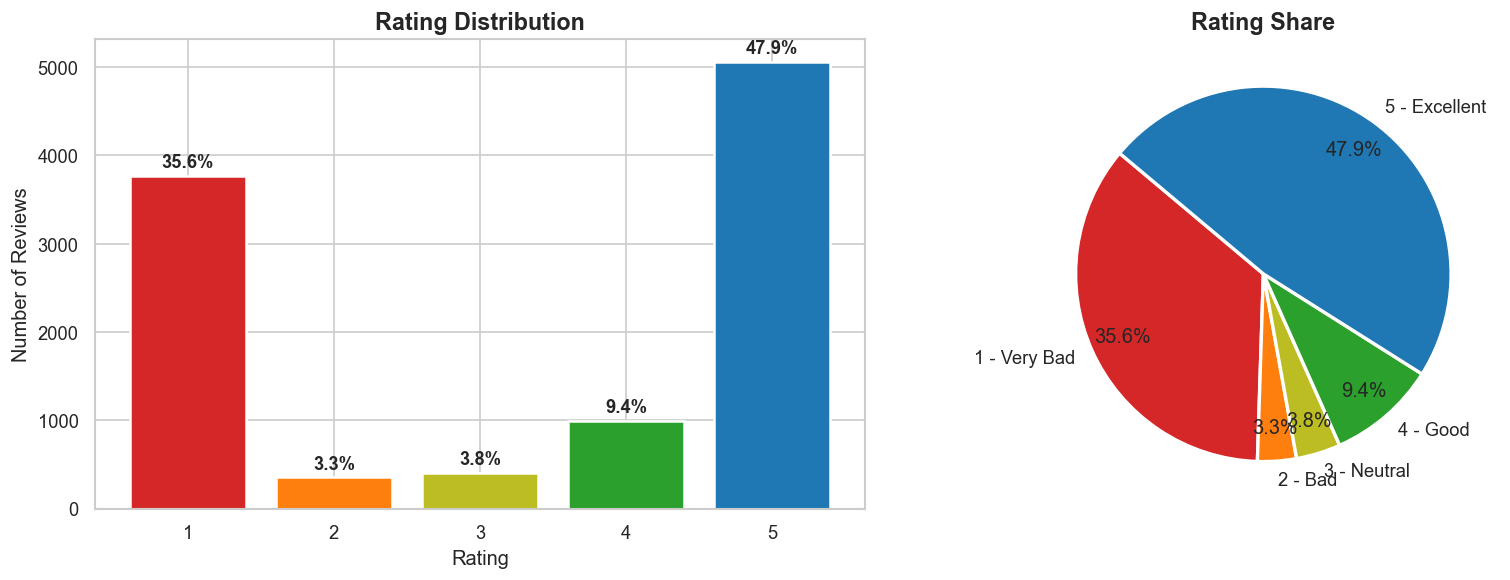


Rating Counts:
  Rating 1: 3,768 reviews (35.6%)
  Rating 2: 354 reviews (3.3%)
  Rating 3: 405 reviews (3.8%)
  Rating 4: 992 reviews (9.4%)
  Rating 5: 5,064 reviews (47.9%)


In [4]:
rating_counts = df['rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(1)

colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']
labels = ['1 - Very Bad', '2 - Bad', '3 - Neutral', '4 - Good', '5 - Excellent']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, rating_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Pie chart
axes[1].pie(rating_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.82,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Rating Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_rating_distribution.png', bbox_inches='tight')
plt.show()

print('\nRating Counts:')
for r, c, p in zip(rating_counts.index, rating_counts.values, rating_pct.values):
    print(f'  Rating {r}: {c:,} reviews ({p}%)')

## 3. Sentiment Segmentation

       OVERALL SENTIMENT SUMMARY
  Total Reviews     : 10,583
  Positive (4-5)    : 6,056  (57.2%)
  Neutral  (3)      : 405  (3.8%)
  Negative (1-2)    : 4,122  (38.9%)
  Avg Rating        : 3.31 / 5.00


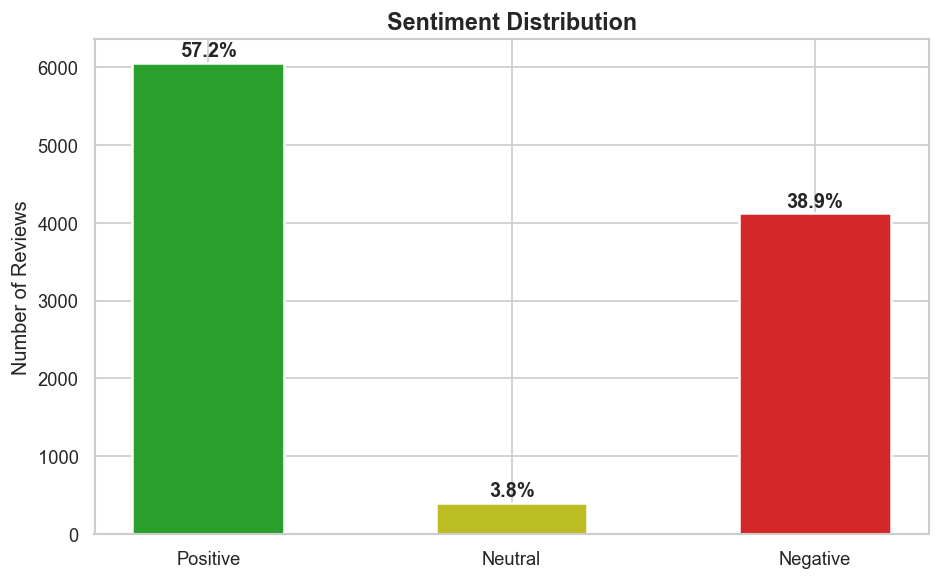

In [5]:
def assign_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(assign_sentiment)

sent_counts = df['sentiment'].value_counts()
sent_pct = (sent_counts / len(df) * 100).round(1)

print('='*45)
print('       OVERALL SENTIMENT SUMMARY')
print('='*45)
print(f'  Total Reviews     : {len(df):,}')
print(f'  Positive (4-5)    : {sent_counts.get("Positive",0):,}  ({sent_pct.get("Positive",0)}%)')
print(f'  Neutral  (3)      : {sent_counts.get("Neutral",0):,}  ({sent_pct.get("Neutral",0)}%)')
print(f'  Negative (1-2)    : {sent_counts.get("Negative",0):,}  ({sent_pct.get("Negative",0)}%)')
print(f'  Avg Rating        : {df["rating"].mean():.2f} / 5.00')
print('='*45)

# Sentiment bar
fig, ax = plt.subplots(figsize=(8, 5))
sent_order = ['Positive', 'Neutral', 'Negative']
sent_colors = {'Positive': '#2ca02c', 'Neutral': '#bcbd22', 'Negative': '#d62728'}
vals = [sent_counts.get(s, 0) for s in sent_order]
bars = ax.bar(sent_order, vals, color=[sent_colors[s] for s in sent_order], edgecolor='white', linewidth=1.5, width=0.5)
for bar, pct in zip(bars, [sent_pct.get(s, 0) for s in sent_order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pct}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_sentiment_distribution.png', bbox_inches='tight')
plt.show()

## 4. TextBlob Polarity Scores

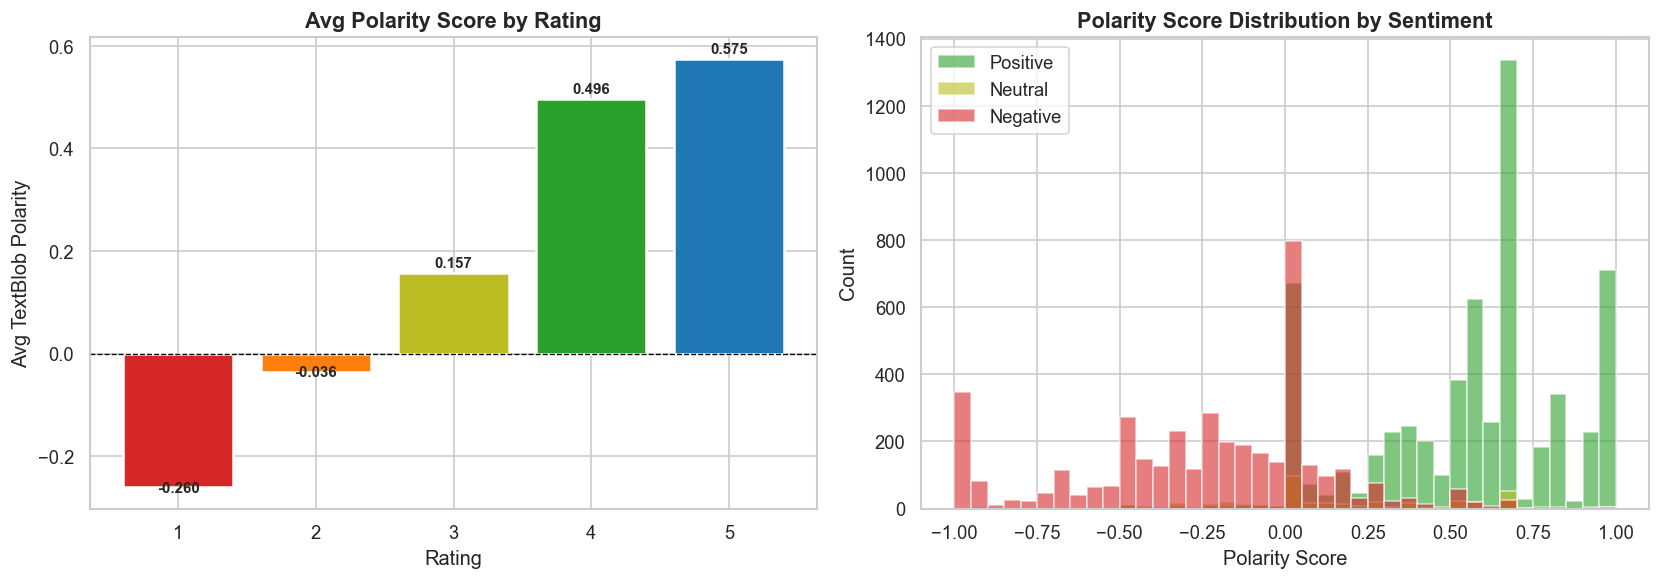

Avg polarity by sentiment:
            mean  median    std
sentiment                      
Negative  -0.241  -0.175  0.377
Neutral    0.157   0.067  0.369
Positive   0.562   0.600  0.307


In [6]:
df['polarity'] = df['body'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['body'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarity by rating
avg_polarity = df.groupby('rating')['polarity'].mean()
colors_r = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']
bars = axes[0].bar(avg_polarity.index, avg_polarity.values, color=colors_r, edgecolor='white', linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, avg_polarity.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.015,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Avg TextBlob Polarity', fontsize=12)
axes[0].set_title('Avg Polarity Score by Rating', fontsize=13, fontweight='bold')

# Polarity distribution
for sent, color in sent_colors.items():
    subset = df[df['sentiment'] == sent]['polarity']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=sent, edgecolor='white')
axes[1].set_xlabel('Polarity Score', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Polarity Score Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('03_polarity_scores.png', bbox_inches='tight')
plt.show()

print('Avg polarity by sentiment:')
print(df.groupby('sentiment')['polarity'].agg(['mean', 'median', 'std']).round(3))

## 5. Review Length Analysis

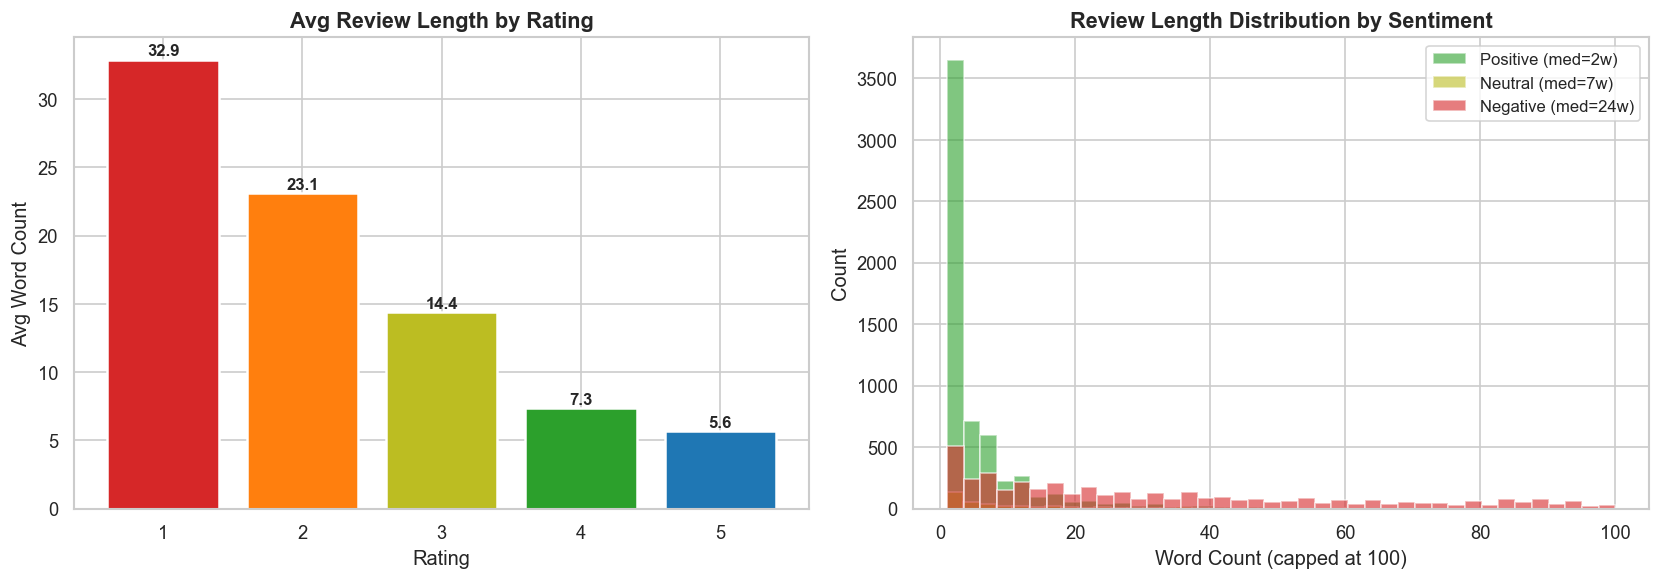


Review length stats by sentiment:
           mean  median  max
sentiment                   
Negative   32.0    23.5  103
Neutral    14.4     7.0   98
Positive    5.9     2.0  110


In [7]:
df['review_length'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg word count by rating
avg_wc = df.groupby('rating')['word_count'].mean()
axes[0].bar(avg_wc.index, avg_wc.values, color=colors_r, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Avg Word Count', fontsize=12)
axes[0].set_title('Avg Review Length by Rating', fontsize=13, fontweight='bold')
for i, v in zip(avg_wc.index, avg_wc.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

# Word count distribution by sentiment
for sent, color in sent_colors.items():
    subset = df[df['sentiment'] == sent]['word_count']
    axes[1].hist(subset.clip(upper=100), bins=40, alpha=0.6, color=color, label=f'{sent} (med={subset.median():.0f}w)', edgecolor='white')
axes[1].set_xlabel('Word Count (capped at 100)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Review Length Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('04_review_length.png', bbox_inches='tight')
plt.show()

print('\nReview length stats by sentiment:')
print(df.groupby('sentiment')['word_count'].agg(['mean', 'median', 'max']).round(1))

## 6. App Version Performance

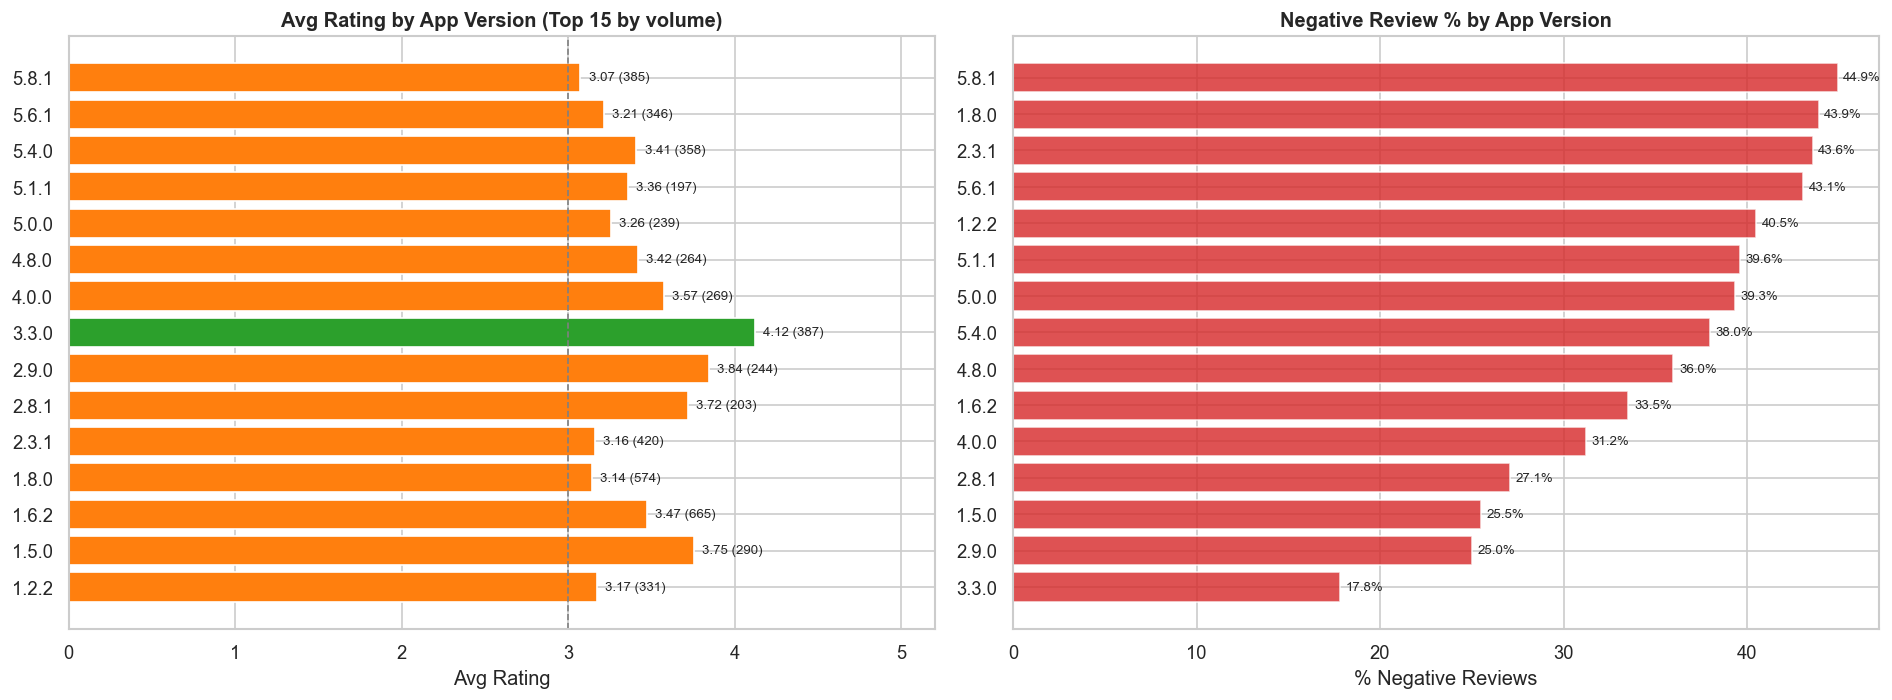


Top 5 best-rated versions (>=30 reviews):
app_version  review_count  avg_rating  pct_negative  pct_positive
      1.0.0            56    4.285714     16.071429     80.357143
      3.6.0           111    4.144144     17.117117     80.180180
      3.3.0           387    4.121447     17.829457     80.103359
      3.1.0           154    4.000000     21.428571     74.675325
      3.7.0           102    3.950980     19.607843     75.490196

Top 5 worst-rated versions (>=30 reviews):
app_version  review_count  avg_rating  pct_negative  pct_positive
      1.9.0           144    2.944444     49.305556     49.305556
      4.1.1            86    2.941860     47.674419     47.674419
      1.7.2            56    2.910714     48.214286     48.214286
      2.2.0            65    2.876923     50.769231     47.692308
      1.3.0           130    2.469231     61.538462     35.384615


In [8]:
version_stats = df.groupby('app_version').agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    pct_negative=('sentiment', lambda x: (x == 'Negative').mean() * 100),
    pct_positive=('sentiment', lambda x: (x == 'Positive').mean() * 100)
).reset_index()

# Only show versions with >=30 reviews
version_stats = version_stats[version_stats['review_count'] >= 30].sort_values('avg_rating', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg rating by version
top_versions = version_stats.nlargest(15, 'review_count').sort_values('app_version')
bar_colors = ['#2ca02c' if r >= 4 else '#ff7f0e' if r >= 3 else '#d62728' for r in top_versions['avg_rating']]
axes[0].barh(top_versions['app_version'], top_versions['avg_rating'], color=bar_colors, edgecolor='white')
axes[0].axvline(3, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Avg Rating', fontsize=12)
axes[0].set_title('Avg Rating by App Version (Top 15 by volume)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 5.2)
for i, (_, row) in enumerate(top_versions.iterrows()):
    axes[0].text(row['avg_rating'] + 0.05, i, f"{row['avg_rating']:.2f} ({int(row['review_count'])})",
                 va='center', fontsize=8)

# Negative % by version
top_neg = version_stats[version_stats['review_count'] >= 30].nlargest(15, 'review_count').sort_values('pct_negative', ascending=True)
axes[1].barh(top_neg['app_version'], top_neg['pct_negative'], color='#d62728', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('% Negative Reviews', fontsize=12)
axes[1].set_title('Negative Review % by App Version', fontsize=12, fontweight='bold')
for i, (_, row) in enumerate(top_neg.iterrows()):
    axes[1].text(row['pct_negative'] + 0.3, i, f"{row['pct_negative']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.savefig('05_version_analysis.png', bbox_inches='tight')
plt.show()

print('\nTop 5 best-rated versions (>=30 reviews):')
print(version_stats.head(5)[['app_version', 'review_count', 'avg_rating', 'pct_negative', 'pct_positive']].to_string(index=False))
print('\nTop 5 worst-rated versions (>=30 reviews):')
print(version_stats.tail(5)[['app_version', 'review_count', 'avg_rating', 'pct_negative', 'pct_positive']].to_string(index=False))

## 7. Text Preprocessing

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)               # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()             # normalize whitespace
    tokens = [w for w in text.split() if w not in ALL_STOP and len(w) > 2]
    return ' '.join(tokens)

df['clean_body'] = df['body'].apply(clean_text)

neg_text = ' '.join(df[df['sentiment'] == 'Negative']['clean_body'])
pos_text = ' '.join(df[df['sentiment'] == 'Positive']['clean_body'])
neu_text = ' '.join(df[df['sentiment'] == 'Neutral']['clean_body'])

print(f'Preprocessed {len(df):,} reviews.')
print(f'Negative corpus: {len(neg_text.split()):,} words')
print(f'Positive corpus: {len(pos_text.split()):,} words')

Preprocessed 10,583 reviews.
Negative corpus: 56,025 words
Positive corpus: 14,864 words


## 8. Word Clouds

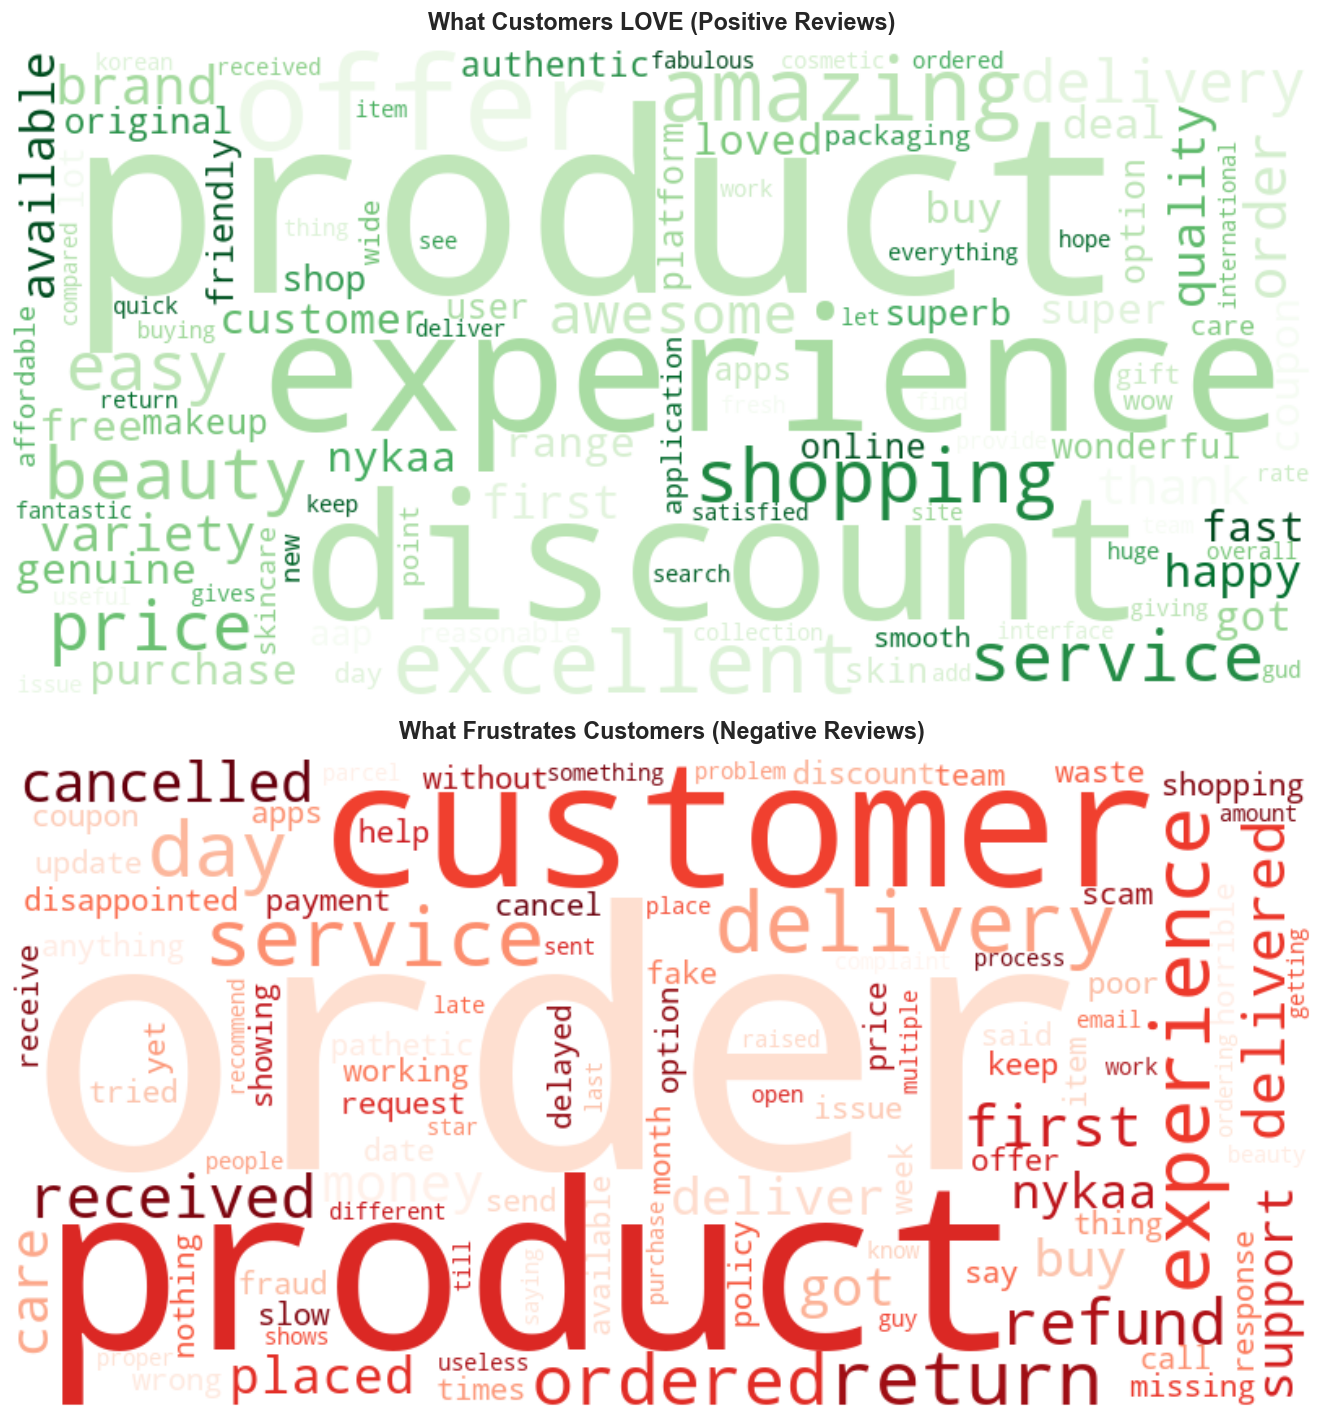

In [10]:
def make_wordcloud(text, colormap, title, ax):
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False,
        min_font_size=8
    ).generate(text if text.strip() else 'no text')
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
make_wordcloud(pos_text, 'Greens', 'What Customers LOVE (Positive Reviews)', axes[0])
make_wordcloud(neg_text, 'Reds', 'What Frustrates Customers (Negative Reviews)', axes[1])
plt.tight_layout()
plt.savefig('06_wordclouds.png', bbox_inches='tight')
plt.show()

## 9. Top Keywords — Positive vs Negative

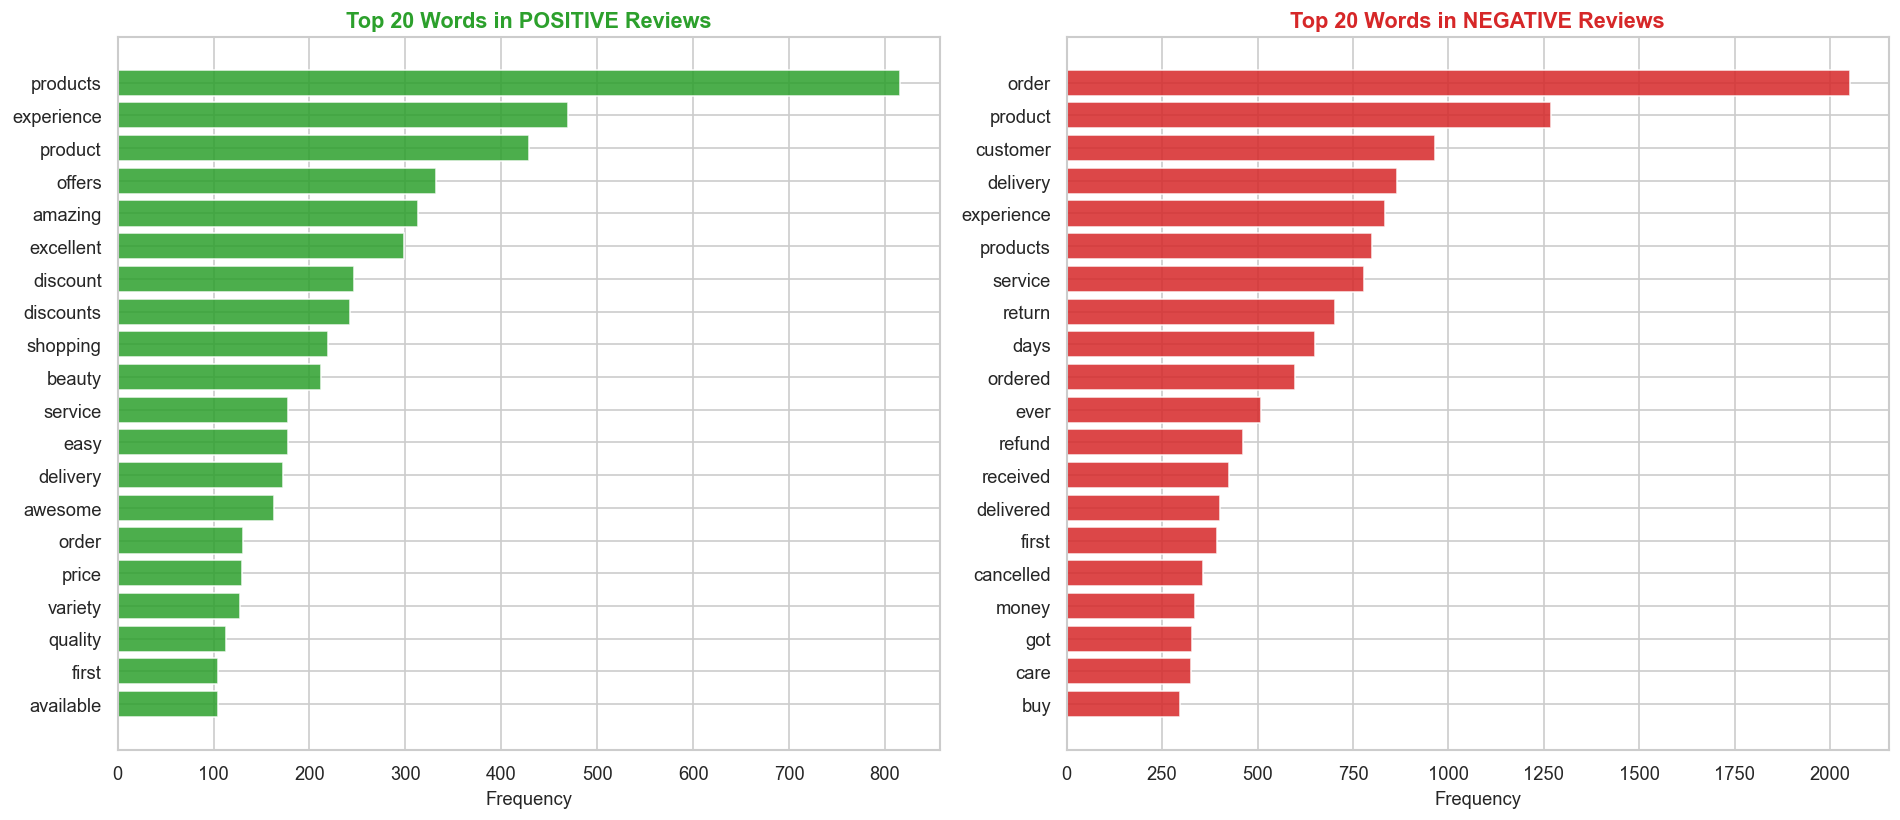

In [11]:
def top_words(text, n=20):
    return Counter(text.split()).most_common(n)

pos_words = top_words(pos_text)
neg_words = top_words(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive
pw, pc = zip(*pos_words)
axes[0].barh(list(pw)[::-1], list(pc)[::-1], color='#2ca02c', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 20 Words in POSITIVE Reviews', fontsize=13, fontweight='bold', color='#2ca02c')
axes[0].set_xlabel('Frequency', fontsize=11)

# Negative
nw, nc = zip(*neg_words)
axes[1].barh(list(nw)[::-1], list(nc)[::-1], color='#d62728', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 20 Words in NEGATIVE Reviews', fontsize=13, fontweight='bold', color='#d62728')
axes[1].set_xlabel('Frequency', fontsize=11)

plt.tight_layout()
plt.savefig('07_top_keywords.png', bbox_inches='tight')
plt.show()

## 10. TF-IDF — Distinctive Keywords per Sentiment

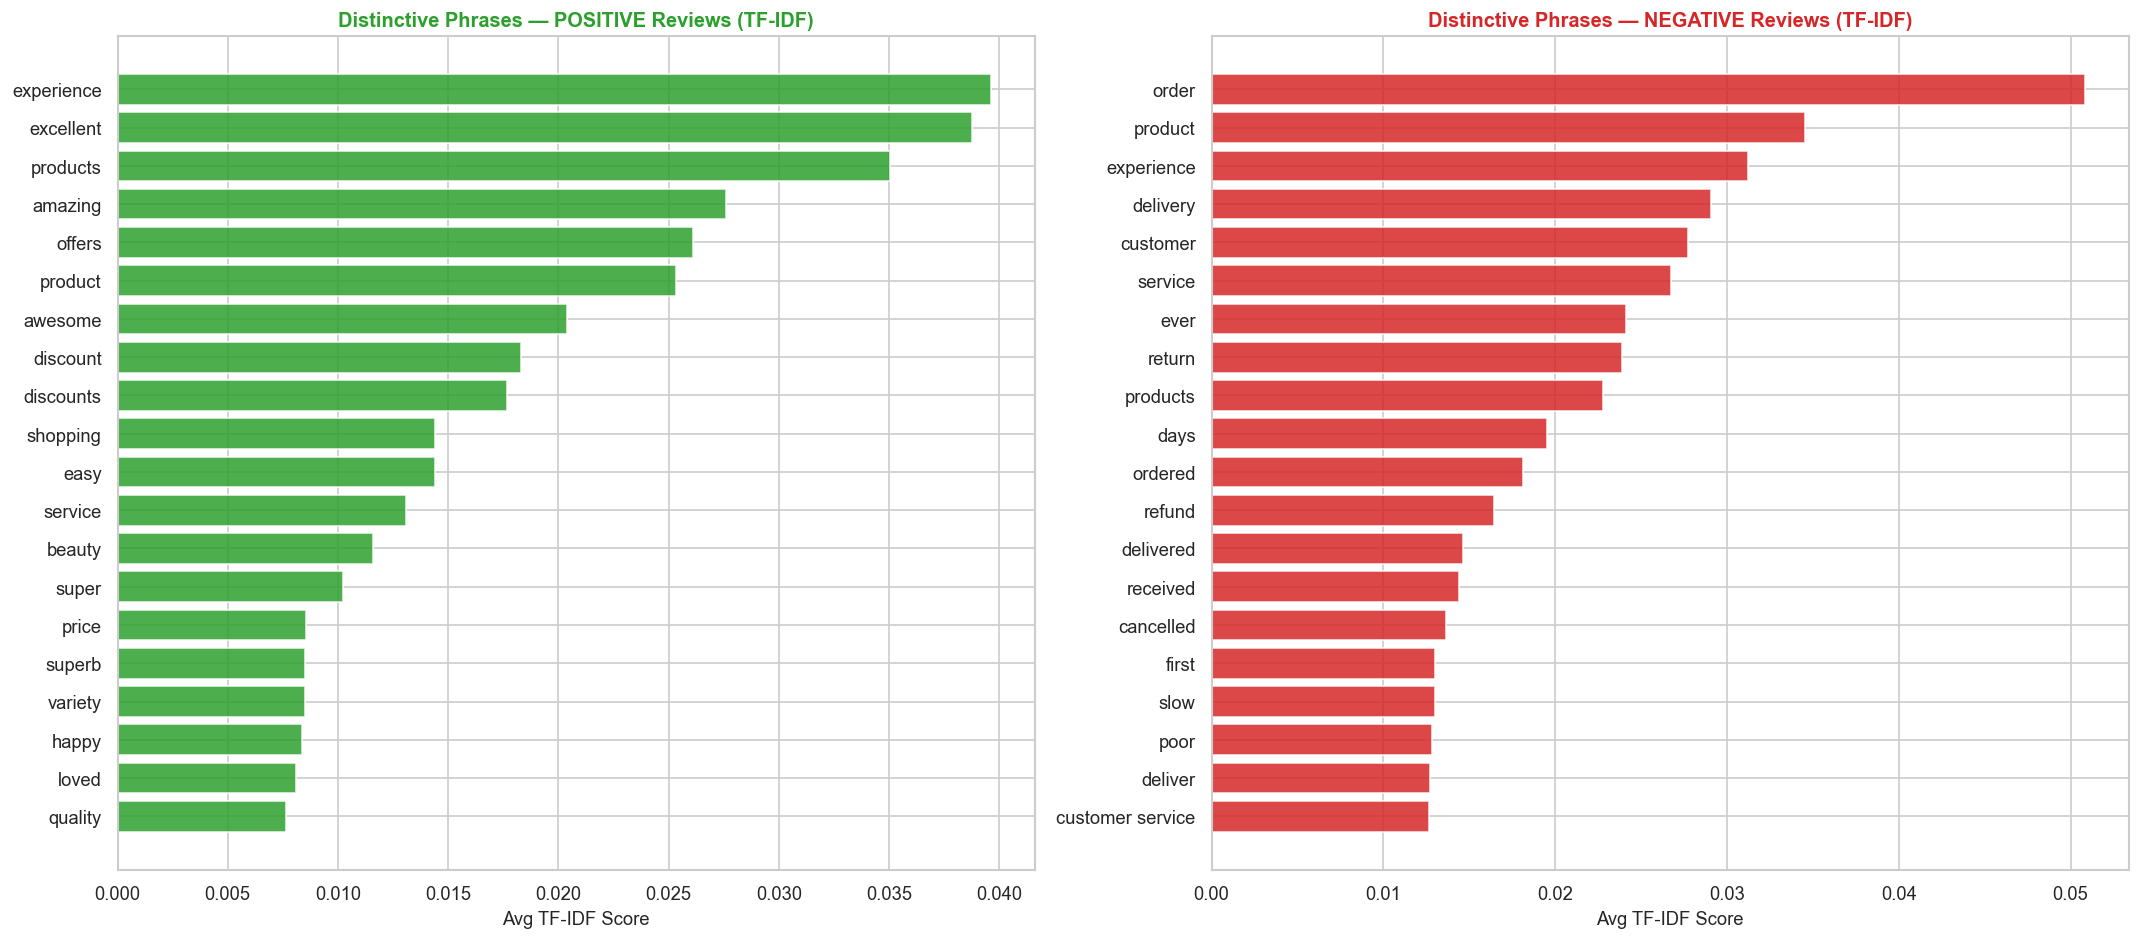


Top distinctive phrases in POSITIVE reviews:
  experience                     0.0396
  excellent                      0.0388
  products                       0.0351
  amazing                        0.0276
  offers                         0.0261
  product                        0.0253
  awesome                        0.0204
  discount                       0.0183
  discounts                      0.0177
  shopping                       0.0144

Top distinctive phrases in NEGATIVE reviews:
  order                          0.0508
  product                        0.0345
  experience                     0.0312
  delivery                       0.0291
  customer                       0.0277
  service                        0.0268
  ever                           0.0241
  return                         0.0239
  products                       0.0228
  days                           0.0195


In [12]:
# TF-IDF: find words that are UNIQUELY characteristic of each sentiment
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
tfidf_matrix = tfidf.fit_transform(df['clean_body'])
feature_names = np.array(tfidf.get_feature_names_out())

def get_top_tfidf(sentiment_label, top_n=20):
    idx = df['sentiment'] == sentiment_label
    mean_tfidf = tfidf_matrix[idx.values].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-top_n:][::-1]
    return list(zip(feature_names[top_idx], mean_tfidf[top_idx]))

pos_tfidf = get_top_tfidf('Positive')
neg_tfidf = get_top_tfidf('Negative')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

pw2, pv2 = zip(*pos_tfidf)
axes[0].barh(list(pw2)[::-1], list(pv2)[::-1], color='#2ca02c', edgecolor='white', alpha=0.85)
axes[0].set_title('Distinctive Phrases — POSITIVE Reviews (TF-IDF)', fontsize=12, fontweight='bold', color='#2ca02c')
axes[0].set_xlabel('Avg TF-IDF Score', fontsize=11)

nw2, nv2 = zip(*neg_tfidf)
axes[1].barh(list(nw2)[::-1], list(nv2)[::-1], color='#d62728', edgecolor='white', alpha=0.85)
axes[1].set_title('Distinctive Phrases — NEGATIVE Reviews (TF-IDF)', fontsize=12, fontweight='bold', color='#d62728')
axes[1].set_xlabel('Avg TF-IDF Score', fontsize=11)

plt.tight_layout()
plt.savefig('08_tfidf_keywords.png', bbox_inches='tight')
plt.show()

print('\nTop distinctive phrases in POSITIVE reviews:')
for phrase, score in pos_tfidf[:10]:
    print(f'  {phrase:<30} {score:.4f}')
print('\nTop distinctive phrases in NEGATIVE reviews:')
for phrase, score in neg_tfidf[:10]:
    print(f'  {phrase:<30} {score:.4f}')

## 11. Theme / Pain Point Detection

In [13]:
# Define keyword-based themes relevant to an e-commerce/beauty app
themes = {
    'Delivery / Shipping':      ['delivery', 'ship', 'shipping', 'deliver', 'courier', 'dispatch', 'arrive', 'arrived', 'late', 'delay', 'delayed'],
    'Payment / Refund':         ['payment', 'refund', 'cashback', 'money', 'pay', 'paid', 'transaction', 'wallet', 'coupon', 'discount', 'offer'],
    'App Performance':          ['crash', 'hang', 'slow', 'bug', 'error', 'loading', 'load', 'freeze', 'glitch', 'issue', 'problem', 'lag'],
    'Product Quality':          ['product', 'quality', 'original', 'fake', 'genuine', 'brand', 'item', 'broken', 'damaged', 'wrong', 'expired'],
    'Customer Support':         ['support', 'service', 'customer', 'help', 'response', 'team', 'complaint', 'helpline', 'contact', 'chat', 'call'],
    'UI / User Experience':     ['interface', 'design', 'experience', 'easy', 'difficult', 'navigate', 'search', 'filter', 'layout', 'simple', 'confusing'],
    'Pincode / Availability':   ['pincode', 'pin code', 'area', 'location', 'available', 'unavailable', 'serviceable', 'city', 'zone'],
    'Order / Returns':          ['order', 'return', 'exchange', 'cancel', 'cancelled', 'replacement', 'wrong order', 'missing'],
    'Login / Account':          ['login', 'otp', 'account', 'sign', 'password', 'verify', 'register', 'logout'],
    'Offers / Discounts':       ['offer', 'sale', 'discount', 'coupon', 'deal', 'promo', 'cashback', 'reward', 'point', 'points'],
}

def detect_theme(text):
    text_l = text.lower()
    matched = []
    for theme, keywords in themes.items():
        if any(kw in text_l for kw in keywords):
            matched.append(theme)
    return matched if matched else ['Other']

df['themes'] = df['body'].apply(detect_theme)

# Explode themes for counting
theme_df = df.explode('themes')

# Theme counts by sentiment
theme_sent = theme_df.groupby(['themes', 'sentiment']).size().unstack(fill_value=0)
theme_sent['total'] = theme_sent.sum(axis=1)
theme_sent = theme_sent.sort_values('total', ascending=False)

# Normalize
theme_norm = theme_sent[['Positive', 'Neutral', 'Negative']].div(theme_sent['total'], axis=0) * 100

print('Theme Distribution (% by sentiment):')
print(theme_norm.round(1).to_string())

Theme Distribution (% by sentiment):
sentiment               Positive  Neutral  Negative
themes                                             
Other                       81.4      3.4      15.3
Product Quality             40.8      3.8      55.4
Order / Returns              7.4      2.3      90.4
Payment / Refund            43.0      3.0      54.0
Customer Support            15.5      2.2      82.4
Offers / Discounts          52.3      3.1      44.7
UI / User Experience        41.5      3.1      55.4
Delivery / Shipping         14.3      3.8      81.9
App Performance              8.8      8.1      83.2
Pincode / Availability      36.2      7.1      56.6
Login / Account              5.4      4.8      89.8


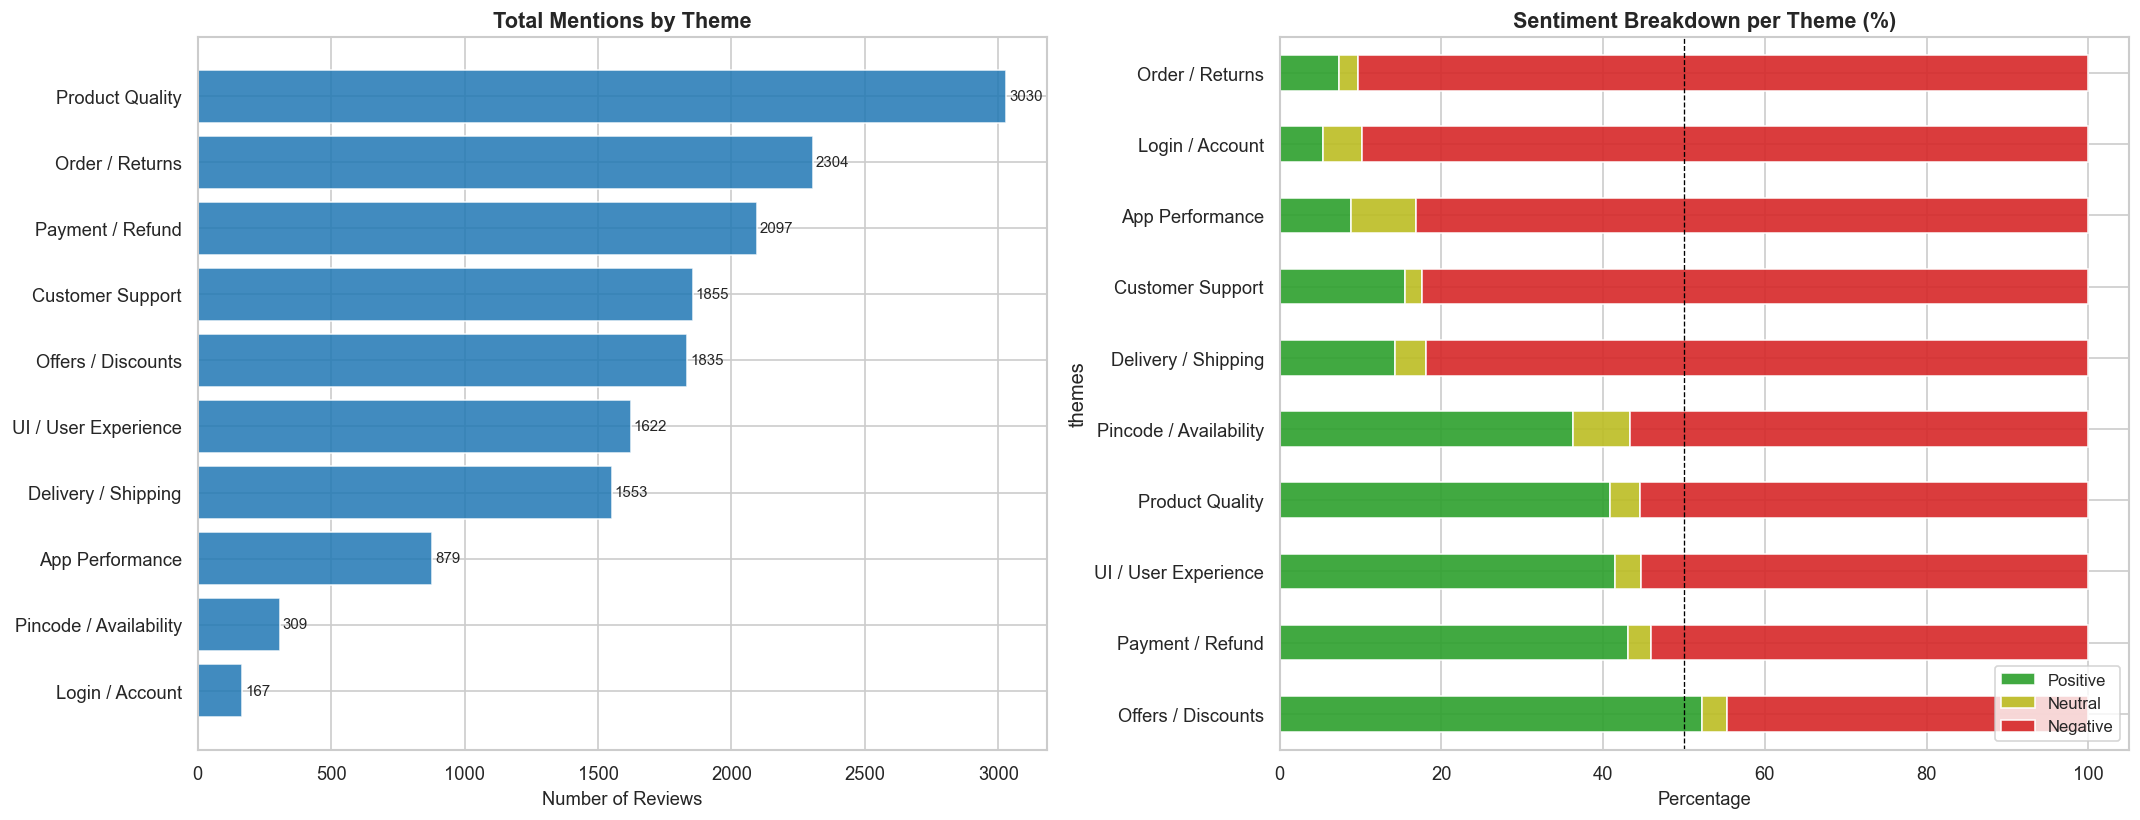

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Total mentions by theme
theme_totals = theme_sent['total'].sort_values(ascending=True)
theme_totals = theme_totals[theme_totals.index != 'Other']
axes[0].barh(theme_totals.index, theme_totals.values, color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0].set_title('Total Mentions by Theme', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews', fontsize=11)
for i, v in enumerate(theme_totals.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Stacked % bar — sentiment breakdown per theme
plot_data = theme_norm.drop('Other', errors='ignore').sort_values('Negative', ascending=True)
plot_data[['Positive', 'Neutral', 'Negative']].plot(
    kind='barh', stacked=True, ax=axes[1],
    color=['#2ca02c', '#bcbd22', '#d62728'],
    edgecolor='white', alpha=0.9
)
axes[1].set_title('Sentiment Breakdown per Theme (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage', fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].axvline(50, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('09_theme_analysis.png', bbox_inches='tight')
plt.show()

## 12. Pain Points — Negative Review Deep Dive

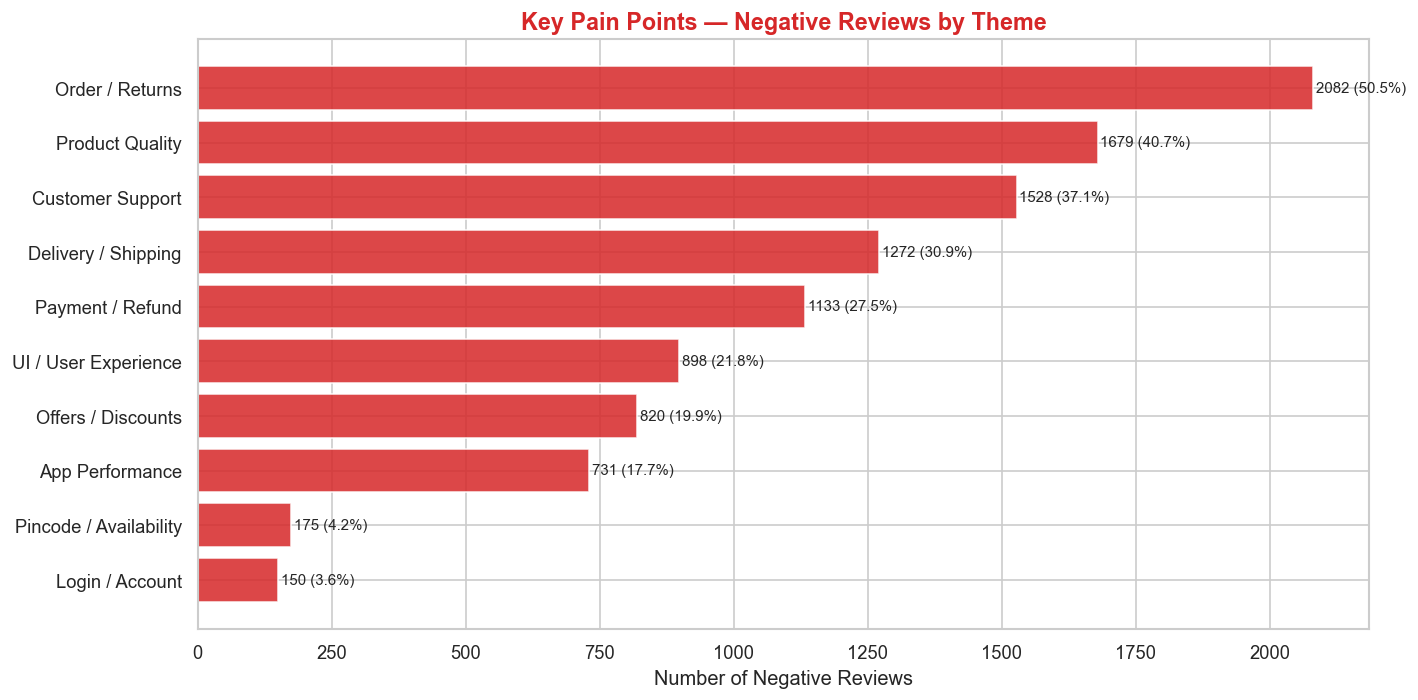


Top Pain Points (Negative Reviews):
  Order / Returns                 2082 reviews  (50.5%)
  Product Quality                 1679 reviews  (40.7%)
  Customer Support                1528 reviews  (37.1%)
  Delivery / Shipping             1272 reviews  (30.9%)
  Payment / Refund                1133 reviews  (27.5%)
  UI / User Experience             898 reviews  (21.8%)
  Offers / Discounts               820 reviews  (19.9%)
  App Performance                  731 reviews  (17.7%)
  Pincode / Availability           175 reviews  (4.2%)
  Login / Account                  150 reviews  (3.6%)


In [15]:
neg_df = df[df['sentiment'] == 'Negative'].copy()
neg_theme_df = neg_df.explode('themes')
neg_theme_counts = neg_theme_df[neg_theme_df['themes'] != 'Other']['themes'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
neg_theme_counts_sorted = neg_theme_counts.sort_values(ascending=True)
bars = ax.barh(neg_theme_counts_sorted.index, neg_theme_counts_sorted.values,
               color='#d62728', edgecolor='white', alpha=0.85)
ax.set_title('Key Pain Points — Negative Reviews by Theme', fontsize=14, fontweight='bold', color='#d62728')
ax.set_xlabel('Number of Negative Reviews', fontsize=12)
total_neg = len(neg_df)
for bar, val in zip(bars, neg_theme_counts_sorted.values):
    pct = val / total_neg * 100
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('10_pain_points.png', bbox_inches='tight')
plt.show()

print('\nTop Pain Points (Negative Reviews):')
for theme, count in neg_theme_counts.head(10).items():
    pct = count / total_neg * 100
    print(f'  {theme:<30} {count:>5} reviews  ({pct:.1f}%)')

## 13. What Customers Love — Positive Review Deep Dive

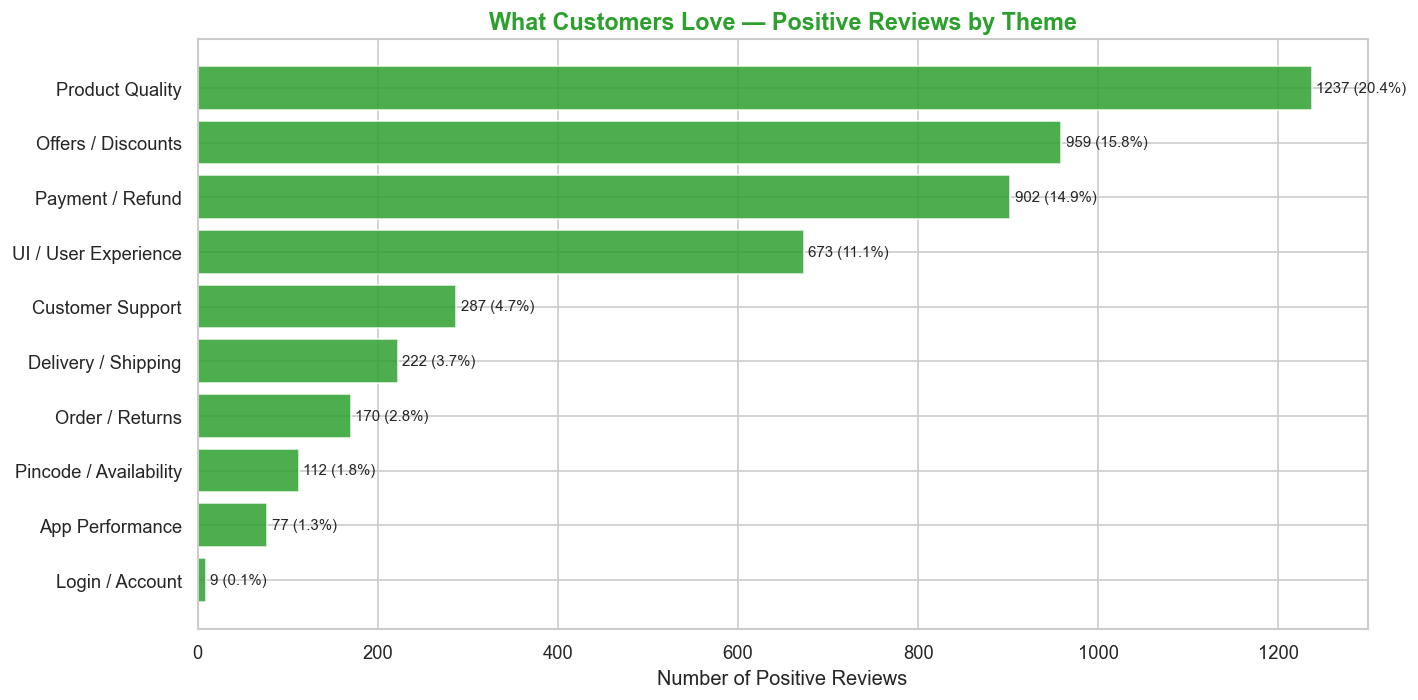


What Customers Love (Positive Reviews):
  Product Quality                 1237 reviews  (20.4%)
  Offers / Discounts               959 reviews  (15.8%)
  Payment / Refund                 902 reviews  (14.9%)
  UI / User Experience             673 reviews  (11.1%)
  Customer Support                 287 reviews  (4.7%)
  Delivery / Shipping              222 reviews  (3.7%)
  Order / Returns                  170 reviews  (2.8%)
  Pincode / Availability           112 reviews  (1.8%)
  App Performance                   77 reviews  (1.3%)
  Login / Account                    9 reviews  (0.1%)


In [16]:
pos_df = df[df['sentiment'] == 'Positive'].copy()
pos_theme_df = pos_df.explode('themes')
pos_theme_counts = pos_theme_df[pos_theme_df['themes'] != 'Other']['themes'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
pos_theme_counts_sorted = pos_theme_counts.sort_values(ascending=True)
bars = ax.barh(pos_theme_counts_sorted.index, pos_theme_counts_sorted.values,
               color='#2ca02c', edgecolor='white', alpha=0.85)
ax.set_title('What Customers Love — Positive Reviews by Theme', fontsize=14, fontweight='bold', color='#2ca02c')
ax.set_xlabel('Number of Positive Reviews', fontsize=12)
total_pos = len(pos_df)
for bar, val in zip(bars, pos_theme_counts_sorted.values):
    pct = val / total_pos * 100
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('11_what_customers_love.png', bbox_inches='tight')
plt.show()

print('\nWhat Customers Love (Positive Reviews):')
for theme, count in pos_theme_counts.head(10).items():
    pct = count / total_pos * 100
    print(f'  {theme:<30} {count:>5} reviews  ({pct:.1f}%)')

## 14. Sample Reviews per Theme

In [17]:
def sample_reviews(theme_name, sentiment_label, n=3):
    subset = df[(df['sentiment'] == sentiment_label) &
                (df['themes'].apply(lambda x: theme_name in x))]
    samples = subset.nlargest(n, 'word_count')[['rating', 'body', 'app_version']]
    return samples

top_pain_themes = neg_theme_counts.head(5).index.tolist()
top_love_themes = pos_theme_counts.head(3).index.tolist()

print('='*70)
print('SAMPLE NEGATIVE REVIEWS BY TOP PAIN POINT THEMES')
print('='*70)
for theme in top_pain_themes:
    print(f'\n--- {theme.upper()} ---')
    samples = sample_reviews(theme, 'Negative', n=2)
    for _, row in samples.iterrows():
        print(f'[Rating {row.rating}] {row.body[:200]}')

print('\n' + '='*70)
print('SAMPLE POSITIVE REVIEWS BY TOP LOVE THEMES')
print('='*70)
for theme in top_love_themes:
    print(f'\n--- {theme.upper()} ---')
    samples = sample_reviews(theme, 'Positive', n=2)
    for _, row in samples.iterrows():
        print(f'[Rating {row.rating}] {row.body[:200]}')

SAMPLE NEGATIVE REVIEWS BY TOP PAIN POINT THEMES

--- ORDER / RETURNS ---
[Rating 1] Hey tira Your app is the worst app Your customer care is also bad And anytime I order something there is problem Like right now I have ordered 8 pcs. Pac take cover compact powder And I recieved only 
[Rating 1] Guys pls don't waste your money here , zero rating. I have placed my order on 29 may . They refunded half of my order and today is 8 June still didn't received it and no updates. I am continuously ema

--- PRODUCT QUALITY ---
[Rating 1] the cosrx face wash product I got seems to be used one I am trying to upload it in the app but unable to do it only if i could upload photo here first the product cover was dirty but I thought maybe i
[Rating 1] Yh app thik he hi he but merko kuch baaten thik nahi lagi matlab mene makeup products order kre and jb mene order kre and inhone kaha ki or show bhi hua ki apko insight ka ek highlighter free milega j

--- CUSTOMER SUPPORT ---
[Rating 1] Hey tira Your ap

## 15. Executive Summary Dashboard

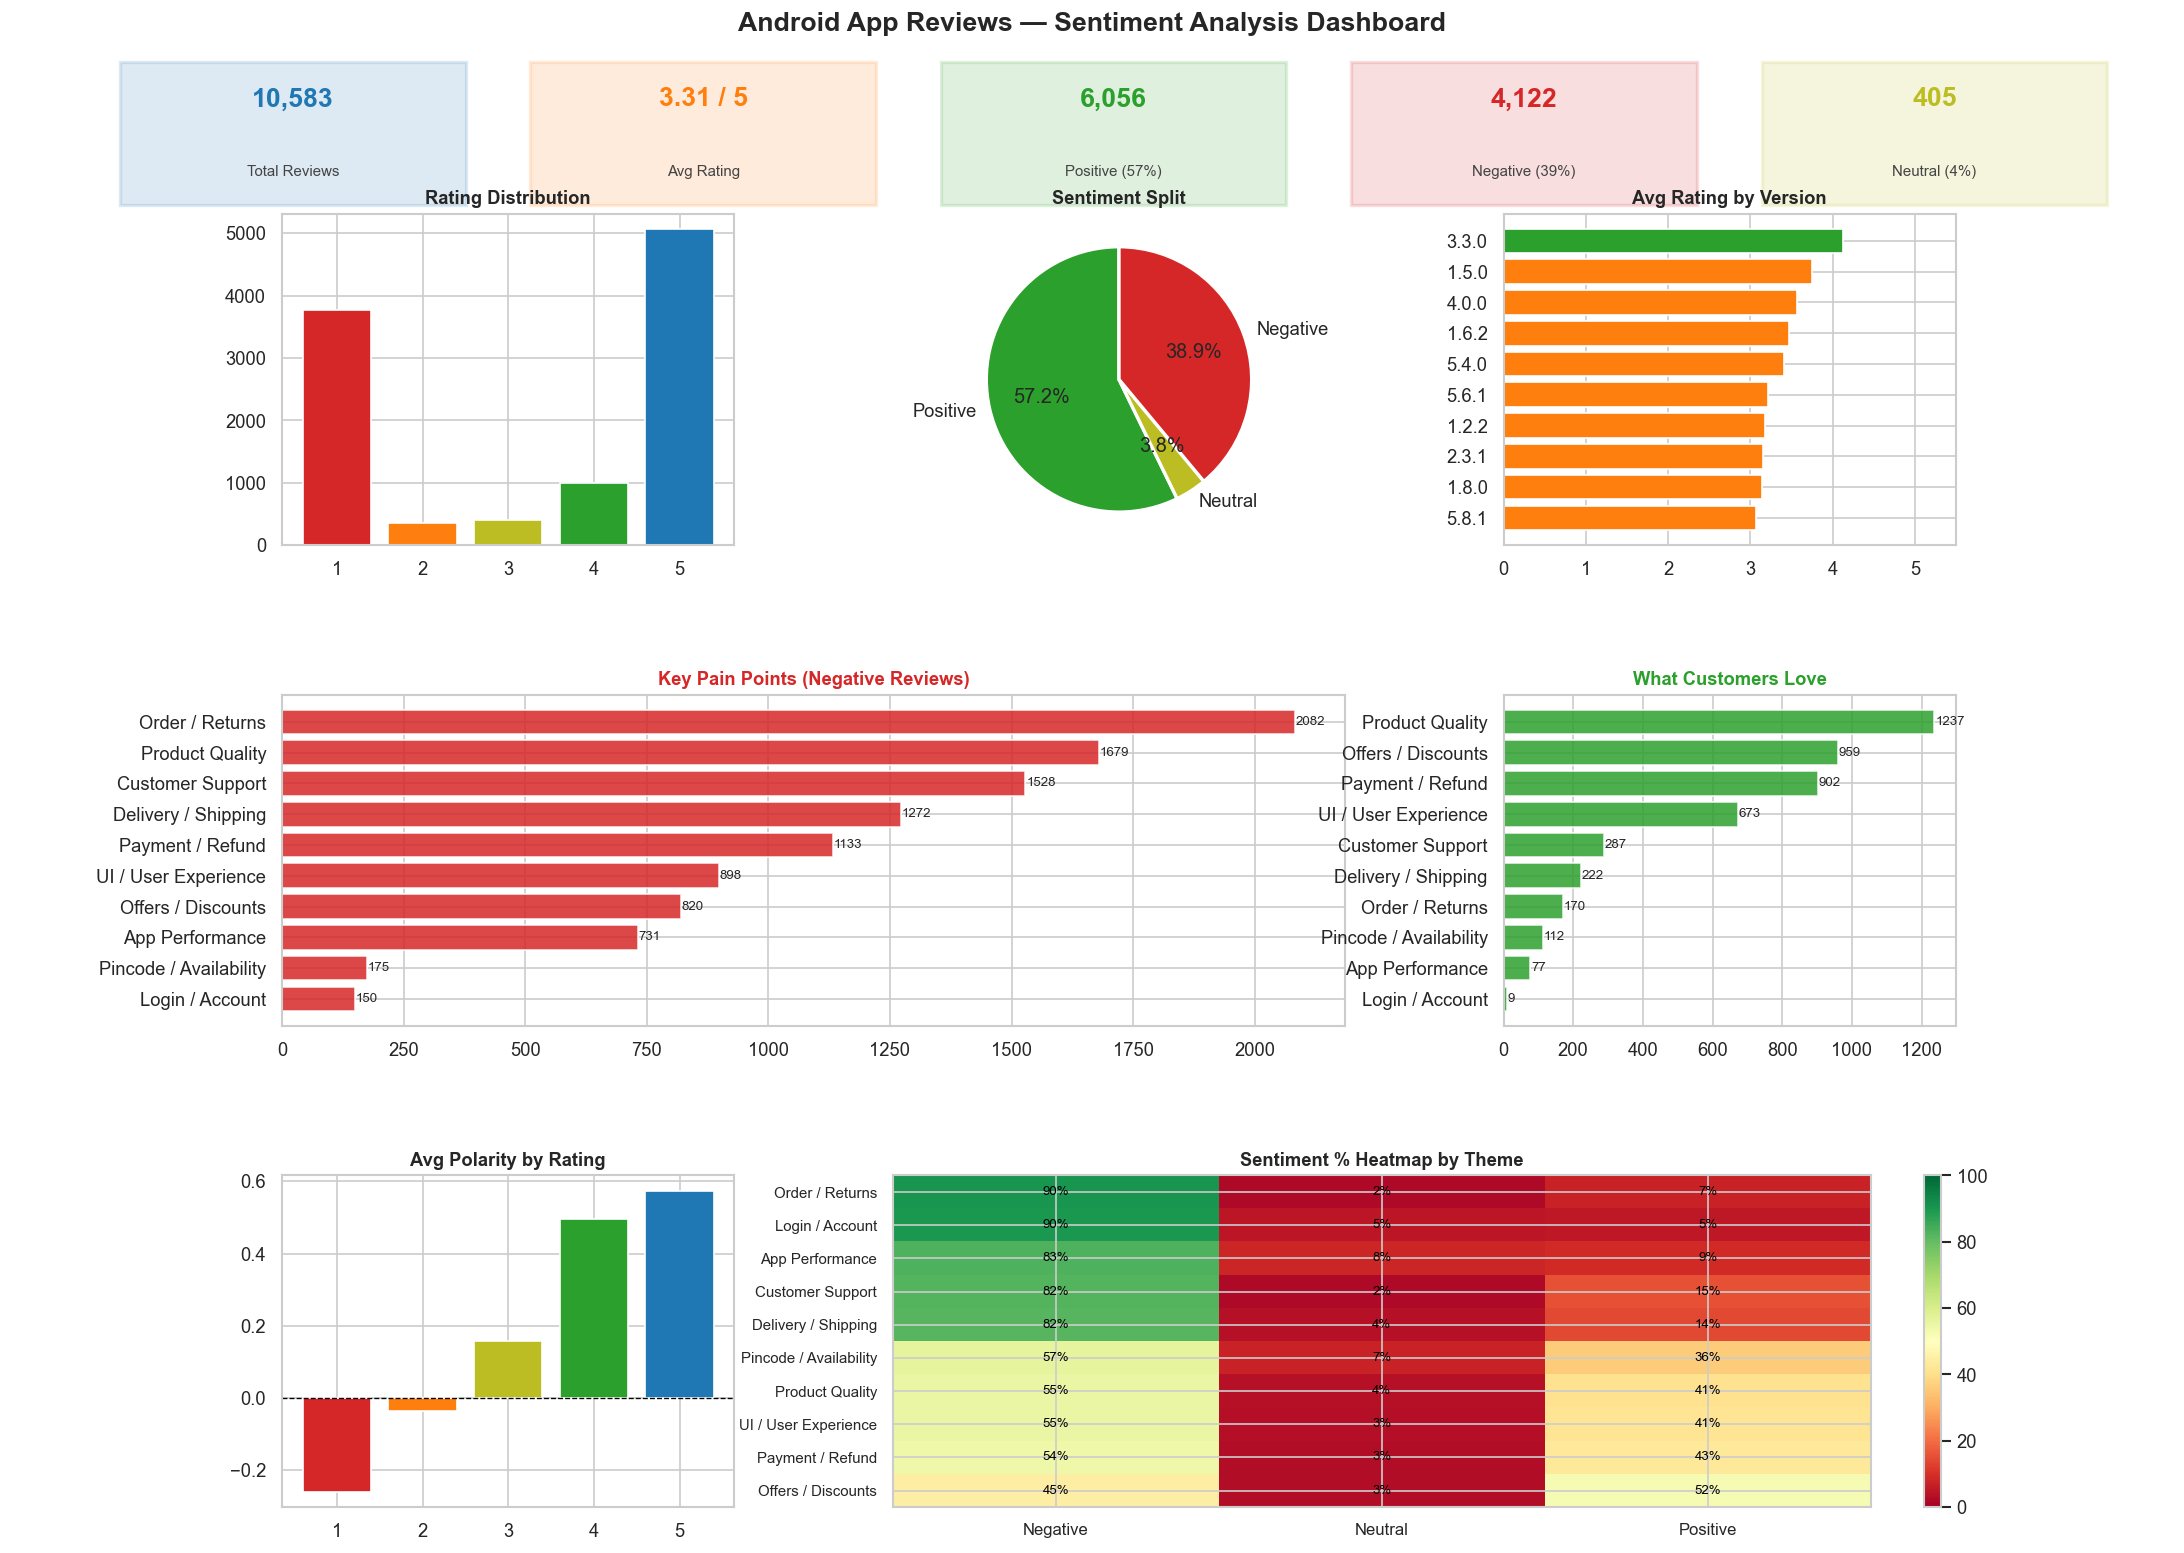

Dashboard saved.


In [18]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- KPI cards (top row) ---
kpi_data = [
    ('Total Reviews', f'{len(df):,}', '#1f77b4'),
    ('Avg Rating', f'{df["rating"].mean():.2f} / 5', '#ff7f0e'),
    (f'Positive ({sent_pct.get("Positive",0):.0f}%)', f'{sent_counts.get("Positive",0):,}', '#2ca02c'),
    (f'Negative ({sent_pct.get("Negative",0):.0f}%)', f'{sent_counts.get("Negative",0):,}', '#d62728'),
    (f'Neutral ({sent_pct.get("Neutral",0):.0f}%)', f'{sent_counts.get("Neutral",0):,}', '#bcbd22'),
]
# Draw KPI boxes at top
kpi_ax = fig.add_axes([0, 0.88, 1, 0.1])
kpi_ax.axis('off')
for i, (label, val, color) in enumerate(kpi_data):
    x = 0.05 + i * 0.19
    kpi_ax.add_patch(plt.Rectangle((x, 0.05), 0.16, 0.85, transform=kpi_ax.transAxes,
                                    color=color, alpha=0.15, linewidth=2, edgecolor=color))
    kpi_ax.text(x + 0.08, 0.68, val, ha='center', va='center', fontsize=16,
                fontweight='bold', color=color, transform=kpi_ax.transAxes)
    kpi_ax.text(x + 0.08, 0.25, label, ha='center', va='center', fontsize=9,
                color='#444', transform=kpi_ax.transAxes)

# --- Rating dist ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(rating_counts.index, rating_counts.values, color=colors_r, edgecolor='white')
ax1.set_title('Rating Distribution', fontweight='bold', fontsize=11)
ax1.set_xticks([1,2,3,4,5])

# --- Sentiment pie ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie([sent_counts.get(s,0) for s in sent_order],
        labels=sent_order, colors=[sent_colors[s] for s in sent_order],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Sentiment Split', fontweight='bold', fontsize=11)

# --- Avg rating by version (top 10) ---
ax3 = fig.add_subplot(gs[0, 2])
top10_v = version_stats.nlargest(10, 'review_count').sort_values('avg_rating')
bc = ['#2ca02c' if r >= 4 else '#ff7f0e' if r >= 3 else '#d62728' for r in top10_v['avg_rating']]
ax3.barh(top10_v['app_version'], top10_v['avg_rating'], color=bc, edgecolor='white')
ax3.set_title('Avg Rating by Version', fontweight='bold', fontsize=11)
ax3.set_xlim(0, 5.5)

# --- Pain points ---
ax4 = fig.add_subplot(gs[1, 0:2])
pp = neg_theme_counts.sort_values(ascending=True)
pp = pp[pp.index != 'Other']
ax4.barh(pp.index, pp.values, color='#d62728', edgecolor='white', alpha=0.85)
ax4.set_title('Key Pain Points (Negative Reviews)', fontweight='bold', fontsize=11, color='#d62728')
for i, v in enumerate(pp.values):
    ax4.text(v+2, i, str(v), va='center', fontsize=8)

# --- What customers love ---
ax5 = fig.add_subplot(gs[1, 2])
pl = pos_theme_counts.sort_values(ascending=True)
pl = pl[pl.index != 'Other']
ax5.barh(pl.index, pl.values, color='#2ca02c', edgecolor='white', alpha=0.85)
ax5.set_title('What Customers Love', fontweight='bold', fontsize=11, color='#2ca02c')
for i, v in enumerate(pl.values):
    ax5.text(v+2, i, str(v), va='center', fontsize=8)

# --- Polarity by rating ---
ax6 = fig.add_subplot(gs[2, 0])
avg_polarity_r = df.groupby('rating')['polarity'].mean()
ax6.bar(avg_polarity_r.index, avg_polarity_r.values, color=colors_r, edgecolor='white')
ax6.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax6.set_title('Avg Polarity by Rating', fontweight='bold', fontsize=11)
ax6.set_xticks([1,2,3,4,5])

# --- Theme sentiment heatmap ---
ax7 = fig.add_subplot(gs[2, 1:])
hm_data = theme_norm.drop('Other', errors='ignore')[['Negative', 'Neutral', 'Positive']].sort_values('Negative', ascending=False)
im = ax7.imshow(hm_data.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax7.set_xticks([0,1,2])
ax7.set_xticklabels(['Negative', 'Neutral', 'Positive'], fontsize=10)
ax7.set_yticks(range(len(hm_data)))
ax7.set_yticklabels(hm_data.index, fontsize=9)
ax7.set_title('Sentiment % Heatmap by Theme', fontweight='bold', fontsize=11)
for i in range(len(hm_data)):
    for j in range(3):
        ax7.text(j, i, f'{hm_data.values[i,j]:.0f}%', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im, ax=ax7, fraction=0.03)

fig.suptitle('Android App Reviews — Sentiment Analysis Dashboard', fontsize=16, fontweight='bold', y=1.0)
plt.savefig('00_executive_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print('Dashboard saved.')

## 16. Key Insights

In [19]:
worst_version = version_stats[version_stats['review_count'] >= 30].nsmallest(1, 'avg_rating').iloc[0]
best_version  = version_stats[version_stats['review_count'] >= 30].nlargest(1, 'avg_rating').iloc[0]
top_pain      = neg_theme_counts.idxmax()
top_love      = pos_theme_counts.idxmax()

print('='*60)
print('        KEY INSIGHTS SUMMARY')
print('='*60)
print(f'\nDataset   : {len(df):,} Android reviews')
print(f'Avg Rating: {df["rating"].mean():.2f} / 5.00')
print(f'\nSentiment Breakdown:')
for s in ['Positive', 'Neutral', 'Negative']:
    print(f'  {s:<10}: {sent_counts.get(s,0):>5,} ({sent_pct.get(s,0):.1f}%)')

print(f'\nBest Version  : {best_version["app_version"]} (avg {best_version["avg_rating"]:.2f}, {int(best_version["review_count"])} reviews)')
print(f'Worst Version : {worst_version["app_version"]} (avg {worst_version["avg_rating"]:.2f}, {int(worst_version["review_count"])} reviews)')

print(f'\nTop Pain Point : {top_pain} ({neg_theme_counts[top_pain]} negative mentions)')
print(f'Top Loved Area : {top_love} ({pos_theme_counts[top_love]} positive mentions)')

print(f'\nNegative Review Characteristics:')
print(f'  Avg polarity  : {df[df.sentiment=="Negative"]["polarity"].mean():.3f}')
print(f'  Avg word count: {df[df.sentiment=="Negative"]["word_count"].mean():.1f} words (users write more when upset)')

print(f'\nTop 5 Pain Points (Negative):')
for t, c in neg_theme_counts.head(5).items():
    print(f'  {t:<30} {c} reviews ({c/total_neg*100:.1f}%)')

print(f'\nTop 5 What Customers Love (Positive):')
for t, c in pos_theme_counts.head(5).items():
    print(f'  {t:<30} {c} reviews ({c/total_pos*100:.1f}%)')

print('\nFiles saved: 00_executive_dashboard.png through 11_what_customers_love.png')
print('='*60)

        KEY INSIGHTS SUMMARY

Dataset   : 10,583 Android reviews
Avg Rating: 3.31 / 5.00

Sentiment Breakdown:
  Positive  : 6,056 (57.2%)
  Neutral   :   405 (3.8%)
  Negative  : 4,122 (38.9%)

Best Version  : 1.0.0 (avg 4.29, 56 reviews)
Worst Version : 1.3.0 (avg 2.47, 130 reviews)

Top Pain Point : Order / Returns (2082 negative mentions)
Top Loved Area : Product Quality (1237 positive mentions)

Negative Review Characteristics:
  Avg polarity  : -0.241
  Avg word count: 32.0 words (users write more when upset)

Top 5 Pain Points (Negative):
  Order / Returns                2082 reviews (50.5%)
  Product Quality                1679 reviews (40.7%)
  Customer Support               1528 reviews (37.1%)
  Delivery / Shipping            1272 reviews (30.9%)
  Payment / Refund               1133 reviews (27.5%)

Top 5 What Customers Love (Positive):
  Product Quality                1237 reviews (20.4%)
  Offers / Discounts             959 reviews (15.8%)
  Payment / Refund              